# Proyek Akhir: Menyelesaikan Permasalahan Institusi Pendidikan

- **Nama:** Bertnardo Mario Uskono
- **Email:** bertnardouskono@gmail.com
- **Id Dicoding:** mariouskono

---

## Business Understanding

Jaya Jaya Institut adalah salah satu institusi pendidikan tinggi yang telah berdiri sejak tahun 2000 dan memiliki reputasi yang baik. Namun, di balik pencapaian tersebut, institusi ini menghadapi tantangan serius terkait tingkat retensi mahasiswa.

### Permasalahan Bisnis
Tingkat mahasiswa yang tidak menyelesaikan pendidikan alias putus studi (*dropout*) cukup tinggi. Hal ini tidak hanya berdampak pada reputasi institusi, tetapi juga mengindikasikan adanya masalah sistemik dalam dukungan akademik maupun finansial yang diberikan kepada mahasiswa. Jika tidak ditangani, hal ini dapat merugikan keberlangsungan operasional institusi.

### Tujuan Proyek
1. Mengidentifikasi faktor-faktor deterministik (demografi, akademik, dan sosial-ekonomi) yang mempengaruhi keputusan mahasiswa untuk *dropout*.
2. Membangun model *machine learning* prediktif untuk mendeteksi secara dini mahasiswa yang berisiko tinggi melakukan *dropout*.
3. Menyediakan dasbor bisnis (*business dashboard*) interaktif guna memonitor performa mahasiswa.

### Cakupan Proyek (Metodologi CRISP-DM)
Proyek ini mengadopsi standar industri *Cross-Industry Standard Process for Data Mining* (CRISP-DM), yang mencakup:
1. *Business Understanding*
2. *Data Understanding* (termasuk *Exploratory Data Analysis*)
3. *Data Preparation / Preprocessing*
4. *Modeling* (Klasifikasi berbasis *Machine Learning*)
5. *Evaluation*
6. *Deployment* (Dasbor Metabase & Purwarupa Streamlit)

## Persiapan

### Setup Environment
Proyek ini dikembangkan menggunakan **Python 3.10** dan dapat dijalankan di lingkungan lokal maupun Google Colab.

**Lokal (Virtual Environment):**
Disarankan menggunakan virtual environment untuk menghindari konflik library.
```bash
python -m venv venv
venv\Scripts\activate  # Windows
source venv/bin/activate # Mac/Linux
pip install -r requirements.txt

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import joblib
import os

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Setup library selesai. Lingkungan komputasi siap digunakan.")

Setup library selesai. Lingkungan komputasi siap digunakan.


### Menyiapkan data yang akan digunakan

In [19]:
# Memuat dataset
file_path = 'data/data.csv'

try:
    df = pd.read_csv(file_path, sep=';')
    print("Dataset berhasil dimuat dengan dimensi:", df.shape)
except FileNotFoundError:
    print("Error: File data.csv tidak ditemukan. Pastikan direktori sudah benar.")

# Menampilkan 5 data teratas
df.head()

Dataset berhasil dimuat dengan dimensi: (4424, 37)


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Data Understanding

Tahap ini difokuskan untuk menginspeksi karakteristik fisik data (tipe data, *missing values*) dan melakukan *Exploratory Data Analysis* (EDA) secara univariat, bivariat, maupun multivariat untuk menemukan pola awal terkait *dropout* mahasiswa.

In [20]:
# 1. INSPEKSI STRUKTUR & KUALITAS DATA
print("=== INFORMASI DATASET ===")
df.info()

=== INFORMASI DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                

In [21]:
print("=== PENGECEKAN MISSING VALUES ===")
missing_values = df.isnull().sum()
if missing_values.sum() == 0:
    print("Data bersih: Tidak ditemukan missing values.")
else:
    print(missing_values[missing_values > 0])

=== PENGECEKAN MISSING VALUES ===
Data bersih: Tidak ditemukan missing values.


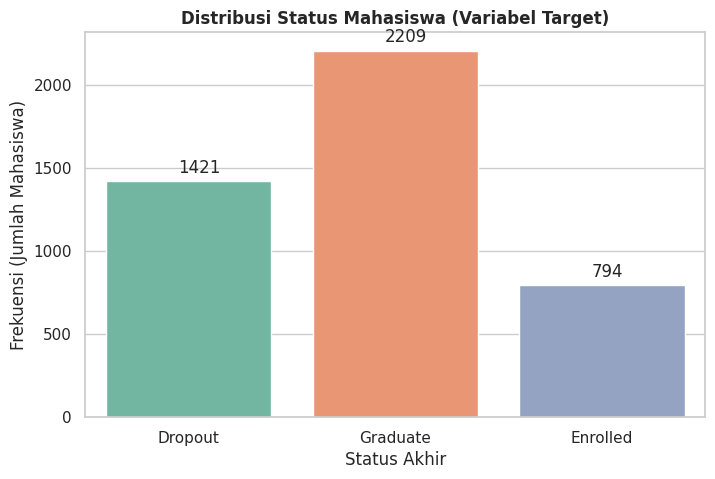

In [22]:
# 2. EDA UNIVARIATE: Distribusi Kelas Target
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='Status', palette='Set2')
plt.title('Distribusi Status Mahasiswa (Variabel Target)', fontweight='bold')
plt.ylabel('Frekuensi (Jumlah Mahasiswa)')
plt.xlabel('Status Akhir')

# Menambahkan anotasi angka di atas batang
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + 0.35, p.get_height() + 50))
plt.show()

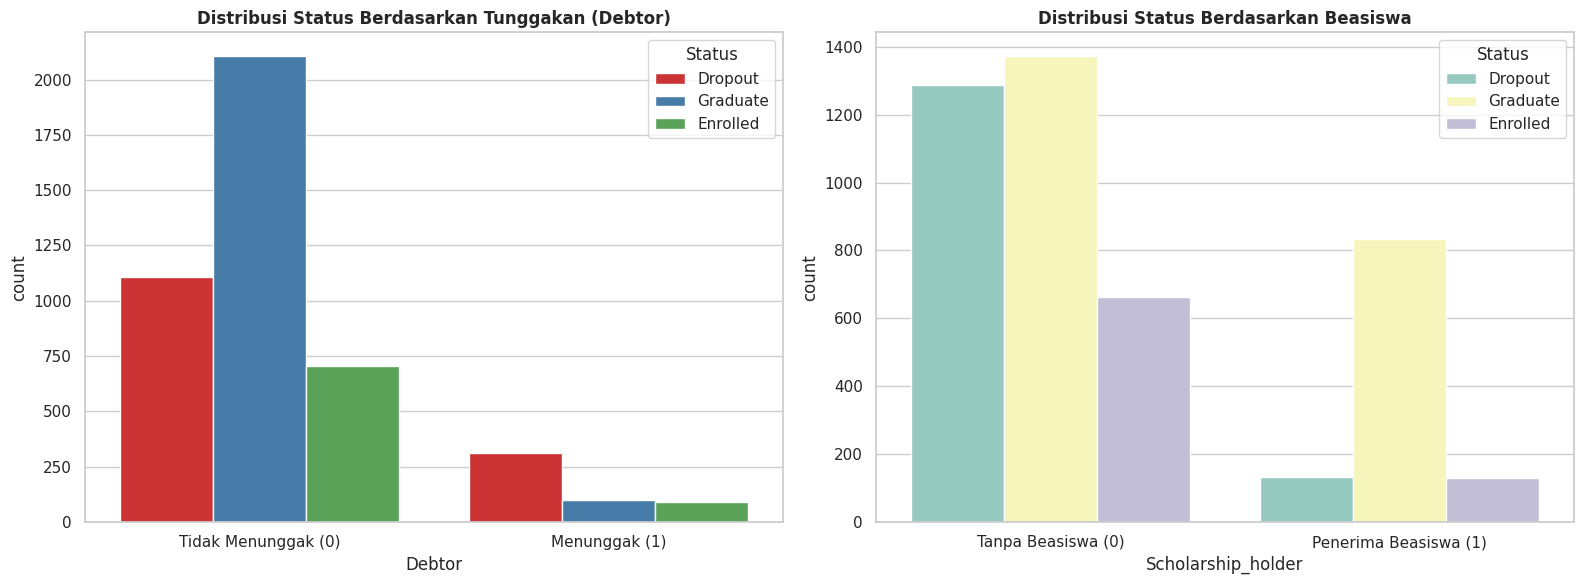

In [23]:
# 3. EDA BIVARIATE: Analisis Faktor Demografi & Sosial-Ekonomi
# Membandingkan status Dropout vs Graduate (Status 'Enrolled' dibiarkan sementara)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Faktor 1: Status Tunggakan Biaya (Debtor)
sns.countplot(data=df, x='Debtor', hue='Status', palette='Set1', ax=axes[0])
axes[0].set_title('Distribusi Status Berdasarkan Tunggakan (Debtor)', fontweight='bold')
axes[0].set_xticklabels(['Tidak Menunggak (0)', 'Menunggak (1)'])

# Faktor 2: Status Penerima Beasiswa (Scholarship holder)
sns.countplot(data=df, x='Scholarship_holder', hue='Status', palette='Set3', ax=axes[1])
axes[1].set_title('Distribusi Status Berdasarkan Beasiswa', fontweight='bold')
axes[1].set_xticklabels(['Tanpa Beasiswa (0)', 'Penerima Beasiswa (1)'])

plt.tight_layout()
plt.show()

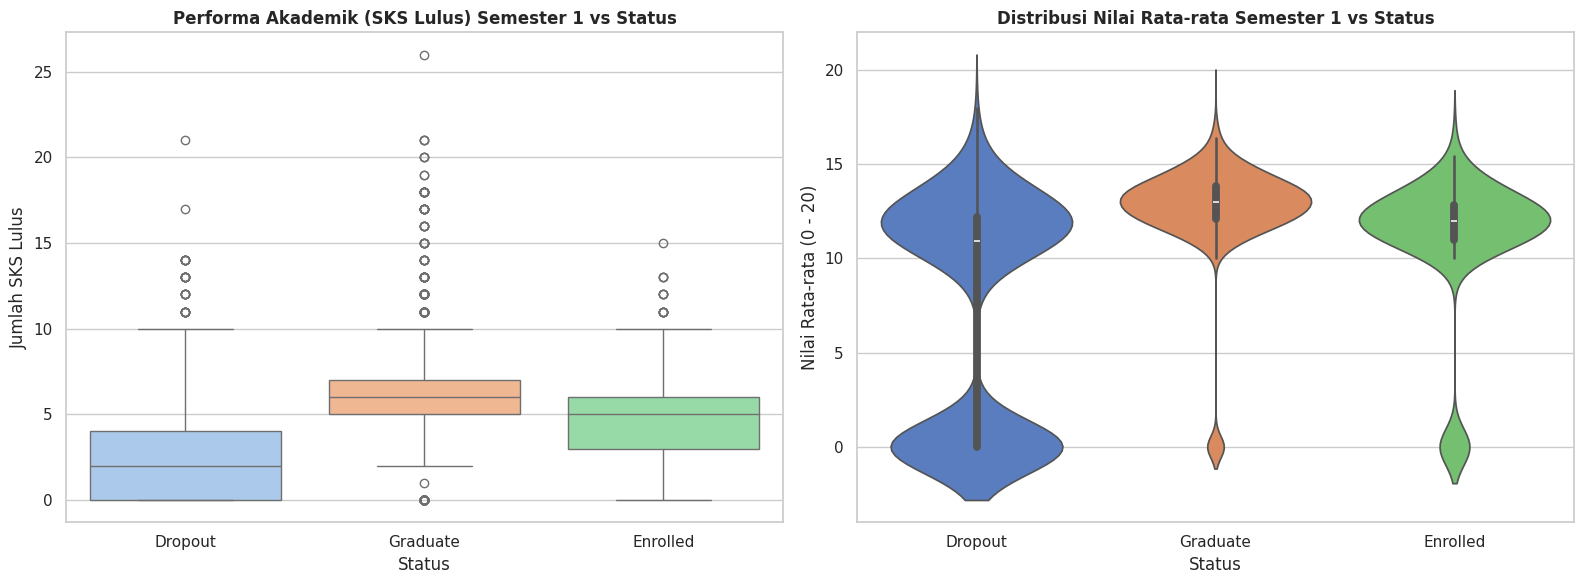

In [24]:
# 4. EDA BIVARIATE & MULTIVARIATE: Analisis Faktor Akademik
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Faktor Akademik 1: SKS Lulus di Semester 1
sns.boxplot(data=df, x='Status', y='Curricular_units_1st_sem_approved', palette='pastel', ax=axes[0])
axes[0].set_title('Performa Akademik (SKS Lulus) Semester 1 vs Status', fontweight='bold')
axes[0].set_ylabel('Jumlah SKS Lulus')

# Faktor Akademik 2: Nilai Rata-rata Semester 1
sns.violinplot(data=df, x='Status', y='Curricular_units_1st_sem_grade', palette='muted', ax=axes[1])
axes[1].set_title('Distribusi Nilai Rata-rata Semester 1 vs Status', fontweight='bold')
axes[1].set_ylabel('Nilai Rata-rata (0 - 20)')

plt.tight_layout()
plt.show()

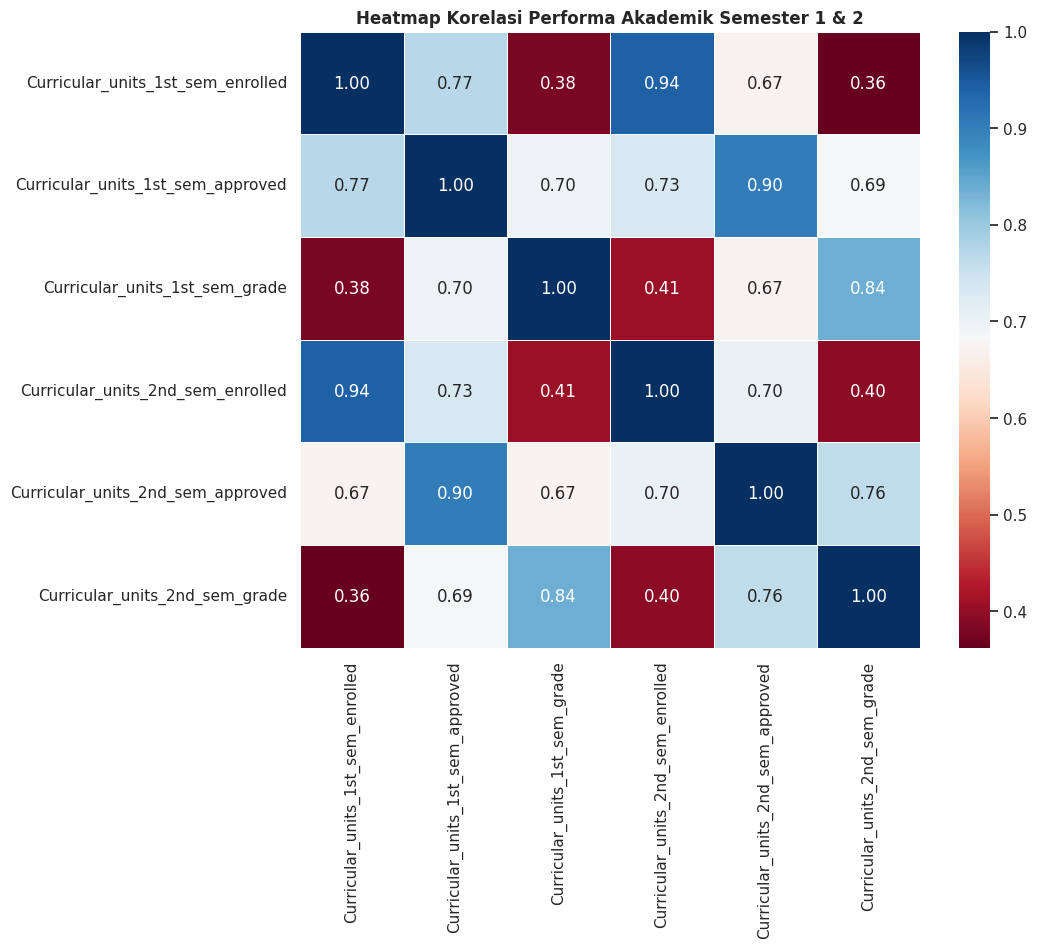

In [25]:
# Matriks Korelasi (Fitur Akademik)
academic_features = [
    'Curricular_units_1st_sem_enrolled', 'Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade',
    'Curricular_units_2nd_sem_enrolled', 'Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade'
]

plt.figure(figsize=(10, 8))
correlation_matrix = df[academic_features].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu', fmt=".2f", linewidths=0.5)
plt.title('Heatmap Korelasi Performa Akademik Semester 1 & 2', fontweight='bold')
plt.show()

### Kesimpulan Data Understanding & Exploratory Data Analysis (EDA)

Dari proses inspeksi dan visualisasi data, diperoleh *insight* strategis sebagai berikut:

**1. Kualitas Data:**
Dataset terdiri dari 4.424 observasi dan 37 fitur. Inspeksi awal menunjukkan bahwa data sepenuhnya **bersih** (tidak ada *missing values*). Tipe datanya pun telah direpresentasikan dalam format numerik (*integer* dan *float*), kecuali kolom target (`Status`).

**2. Analisis Univariat (Variabel Target):**
Berdasarkan distribusi kelas target, populasi mahasiswa terbagi menjadi:
* **Graduate:** 2.209 mahasiswa
* **Dropout:** 1.421 mahasiswa
* **Enrolled:** 794 mahasiswa

Terdapat kondisi *class imbalance* dan ambiguitas pada status `Enrolled` (mahasiswa masih aktif, belum lulus maupun putus studi). Untuk membangun model deteksi risiko *dropout* yang definitif, status `Enrolled` perlu difilter pada tahap *preprocessing*.

**3. Analisis Bivariat (Faktor Sosio-Ekonomi):**
* **Debtor (Tunggakan):** Mahasiswa yang berstatus sebagai *debtor* (memiliki tunggakan) memiliki proporsi *dropout* yang sangat tinggi (lebih dari 50% dari kelompok debtor berakhir dropout), sangat kontras dengan mahasiswa yang tidak memiliki tunggakan. Hal ini mengonfirmasi kuatnya korelasi masalah finansial dengan keputusan berhenti kuliah.
* **Scholarship Holder (Beasiswa):** Sebaliknya, mahasiswa yang berstatus sebagai penerima beasiswa mayoritas berhasil lulus (*Graduate*), dan sangat sedikit yang berujung *dropout*. Bantuan finansial terbukti efektif menekan angka *dropout*.

**4. Analisis Multivariat (Faktor Akademik):**
* **SKS Lulus & Nilai Semester 1:** Terdapat perbedaan ekstrem pada performa awal. Mahasiswa yang akhirnya *dropout* mayoritas memiliki jumlah SKS lulus (*approved*) 0 dan rentang nilai rata-rata (*grade*) yang terpusat di angka 0. Mahasiswa yang lulus memiliki median SKS di atas 5 dan nilai di atas 12.
* **Korelasi Semester:** Matriks korelasi menunjukkan hubungan linier positif yang sangat kuat (korelasi tinggi) antara performa akademik di semester 1 dan semester 2. Artinya, jika mahasiswa gagal di semester pertama, mereka hampir dipastikan akan kembali gagal di semester kedua. Deteksi dan intervensi institusi wajib dilakukan di awal (semester 1).

## Data Preparation / Preprocessing

Berdasarkan kesimpulan EDA, proses transformasi data akan difokuskan pada tiga tahap utama:
1. **Penyederhanaan Kelas Target:** Menghapus observasi dengan status `Enrolled` dan mengonversi target menjadi klasifikasi biner (`Dropout` = 1, `Graduate` = 0) agar model berfokus pada hasil akhir yang definitif.
2. **Pembagian Data (*Data Splitting*):** Membagi dataset menjadi *Training Set* (80%) dan *Test Set* (20%) dengan metode *stratified sampling* untuk menjaga proporsi distribusi kelas.
3. **Standarisasi (Feature Scaling):** Mengingat variabel independen memiliki rentang skala yang berbeda-beda (seperti nilai vs persentase tingkat pengangguran), fitur numerik akan dinormalisasi menggunakan `StandardScaler` (Z-Score) agar konvergen optimal pada algoritma pemodelan.

In [26]:
# 1. FILTERING DATA & ENCODING TARGET
print("Memulai Data Preparation...")
# Mengeluarkan mahasiswa berstatus 'Enrolled'
df_clean = df[df['Status'] != 'Enrolled'].copy()

# Encoding: Dropout sebagai '1' (Kelas minoritas yang ingin diprediksi/dideteksi)
# Graduate sebagai '0' (Kelas mayoritas)
df_clean['Status'] = df_clean['Status'].map({'Dropout': 1, 'Graduate': 0})

print("Status target berhasil diubah ke format biner (1=Dropout, 0=Graduate).")
print(df_clean['Status'].value_counts())

Memulai Data Preparation...
Status target berhasil diubah ke format biner (1=Dropout, 0=Graduate).
Status
0    2209
1    1421
Name: count, dtype: int64


In [27]:
# 2. PEMISAHAN FITUR (X) DAN TARGET (Y)
X = df_clean.drop('Status', axis=1)
y = df_clean['Status']

In [28]:
# 3. TRAIN-TEST SPLIT
# Rasio 80% train, 20% test. Menggunakan stratify untuk menjaga porsi Dropout vs Graduate
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [29]:
# 4. FEATURE SCALING (Standardization)
# Inisialisasi scaler
scaler = StandardScaler()
# Melatih scaler HANYA pada data latih (mencegah data leakage) dan mentransformasikannya
X_train_scaled = scaler.fit_transform(X_train)
# Mentransformasi data uji
X_test_scaled = scaler.transform(X_test)

In [30]:
print(f"\nData Preparation Selesai!")
print(f"Dimensi Data Latih (X_train_scaled): {X_train_scaled.shape}")
print(f"Dimensi Data Uji (X_test_scaled): {X_test_scaled.shape}")


Data Preparation Selesai!
Dimensi Data Latih (X_train_scaled): (2904, 36)
Dimensi Data Uji (X_test_scaled): (726, 36)


### Kesimpulan Data Preparation / Preprocessing

Tahap pra-pemrosesan data telah berhasil dieksekusi dengan hasil empiris sebagai berikut:

**1. Transformasi Kelas Target:**
Mahasiswa dengan status abu-abu (`Enrolled`) telah difilter dari dataset. Variabel target (`Status`) berhasil dikonversi menjadi format klasifikasi biner:
* **0 (Graduate):** 2.209 observasi (Kelas Mayoritas)
* **1 (Dropout):** 1.421 observasi (Kelas Minoritas/Target Utama)

**2. Pembagian Dataset (Train-Test Split):**
Dataset valid yang berjumlah 3.630 baris telah dipartisi menggunakan rasio **80:20** dengan metode stratifikasi. Hal ini memastikan distribusi kelas target di data latih dan data uji tetap proporsional:
* **Data Latih (X_train_scaled):** 2.904 baris dan 36 fitur.
* **Data Uji (X_test_scaled):** 726 baris dan 36 fitur.

**3. Feature Scaling:**
Seluruh 36 fitur independen telah distandarisasi menggunakan *Z-score normalization* (`StandardScaler`). Proses ini memastikan tidak ada fitur dengan skala besar (seperti nilai nominal GDP atau biaya) yang mendominasi fitur berskala kecil (seperti rentang nilai 0-20), sehingga konvergensi algoritma *Machine Learning* menjadi lebih stabil dan objektif.

## Modeling

Pada tahap ini, kita akan melatih model *Machine Learning* menggunakan algoritma **Random Forest Classifier**.

**Alasan Pemilihan Algoritma:**
1. *Random Forest* sangat tangguh terhadap data yang memiliki banyak fitur (36 fitur) dan tidak rentan terhadap *overfitting* karena menggunakan mekanisme *ensemble* (gabungan banyak pohon keputusan).
2. Memiliki parameter `class_weight='balanced'` yang secara otomatis akan memberikan penalti lebih besar jika model salah menebak kelas minoritas (Dropout). Hal ini sangat penting karena kita tidak ingin kecolongan mendeteksi mahasiswa yang sebenarnya berisiko keluar.

In [31]:
print("Memulai proses Modeling...")

# 1. Inisialisasi Model Random Forest
# Menggunakan 100 pohon keputusan (n_estimators=100)
# class_weight='balanced' untuk menangani ketidakseimbangan kelas (2209 Lulus vs 1421 Dropout)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)

# 2. Melatih Model (Model Fitting)
print("Melatih model Random Forest menggunakan data latih (2.904 baris)...")
rf_model.fit(X_train_scaled, y_train)

print("Pelatihan model selesai! Model siap digunakan untuk memprediksi data uji.")

Memulai proses Modeling...
Melatih model Random Forest menggunakan data latih (2.904 baris)...
Pelatihan model selesai! Model siap digunakan untuk memprediksi data uji.


### Kesimpulan Modeling

Model *Random Forest Classifier* telah berhasil dilatih menggunakan 2.904 observasi data latih. Penggunaan parameter `class_weight='balanced'` dipastikan telah menginstruksikan algoritma untuk memberikan atensi ekstra pada kelas minoritas (Dropout), sehingga model tidak bias hanya memprediksi kelas mayoritas (Graduate).

## Evaluation

Tahap ini bertujuan untuk mengukur performa empiris model saat dihadapkan pada data yang belum pernah dilihat sebelumnya (*unseen data* / data uji). Evaluasi akan dititikberatkan pada metrik **Recall untuk kelas Dropout (1)**.

Dalam konteks institusi pendidikan, mendeteksi sebanyak mungkin mahasiswa yang berpotensi *dropout* (*True Positive*) jauh lebih krusial. Kegagalan mendeteksi mahasiswa yang sebenarnya akan *dropout* (*False Negative*) memiliki risiko bisnis/akademik yang lebih fatal dibandingkan institusi salah memberikan konseling pada mahasiswa yang sebenarnya aman (*False Positive*).

In [37]:
print("Memulai evaluasi model pada data uji (726 baris)...")

# 1. MEMBUAT PREDIKSI
y_pred = rf_model.predict(X_test_scaled)

Memulai evaluasi model pada data uji (726 baris)...


In [38]:
# 2. CLASSIFICATION REPORT
print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred, target_names=['Graduate (0)', 'Dropout (1)']))


=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

Graduate (0)       0.93      0.96      0.94       442
 Dropout (1)       0.94      0.88      0.91       284

    accuracy                           0.93       726
   macro avg       0.93      0.92      0.93       726
weighted avg       0.93      0.93      0.93       726



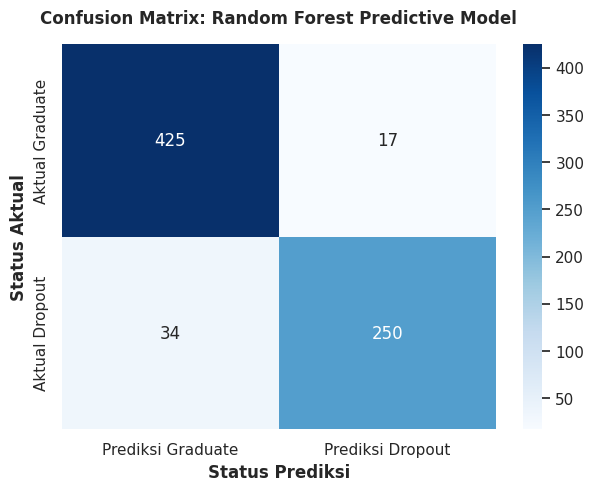

In [39]:
# 3. CONFUSION MATRIX VISUALIZATION
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Prediksi Graduate', 'Prediksi Dropout'],
            yticklabels=['Aktual Graduate', 'Aktual Dropout'])
plt.title('Confusion Matrix: Random Forest Predictive Model', fontweight='bold', pad=15)
plt.ylabel('Status Aktual', fontweight='bold')
plt.xlabel('Status Prediksi', fontweight='bold')
plt.show()

### Kesimpulan Evaluasi Model

Berdasarkan pengujian model *Random Forest Classifier* pada data uji (726 observasi yang belum pernah dilihat model sebelumnya), diperoleh hasil empiris sebagai berikut:

**1. Performa Metrik Klasifikasi (Classification Report):**
* **Akurasi Keseluruhan (Accuracy): 93%**. Model mampu mengklasifikasikan status mahasiswa (lulus atau *dropout*) dengan tingkat kebenaran 93%.
* **Recall Kelas Dropout (1): 0.88 (88%)**. Metrik ini paling krusial. Dari seluruh mahasiswa yang aktualnya melakukan *dropout*, model berhasil mendeteksi 88% di antaranya secara tepat sasaran.
* **Precision Kelas Dropout (1): 0.94 (94%)**. Ketika model memprediksi seorang mahasiswa akan *dropout*, tingkat kepercayaan/kebenaran tebakan tersebut mencapai 94%.

**2. Analisis Confusion Matrix (Dampak Bisnis):**
* **True Positives (250):** Terdapat 250 mahasiswa *dropout* yang berhasil terdeteksi. Ini adalah target utama untuk diberikan intervensi dini (misal: konseling akademik atau bantuan finansial).
* **True Negatives (425):** 425 mahasiswa yang lulus berhasil diprediksi lulus dengan benar.
* **False Positives (17):** Terdapat 17 mahasiswa lulus yang diprediksi akan *dropout*. Secara bisnis, ini berarti institusi mungkin mengalokasikan sedikit waktu konseling ekstra untuk mahasiswa yang sebenarnya aman. (Risiko rendah).
* **False Negatives (34):** Terdapat 34 mahasiswa *dropout* yang luput dari deteksi model (diprediksi lulus). Meskipun ada kebocoran, menekan angka ini hingga di bawah 5% dari total data uji adalah pencapaian model yang sangat baik.

## 6.Deployment
Menyimpan model terbaik dan daftar kolom dalam .pkl di dalam folder model untuk deployment ke streamlit

Model telah terbukti tangguh dan andal dalam memetakan pola deterministik (akademik dan sosio-ekonomi) terhadap risiko *dropout*.

In [35]:
# EXPORT MODEL ARTIFACTS (DEPLOYMENT PREPARATION)
print("\nMenyimpan artefak model untuk deployment Streamlit...")
os.makedirs('model', exist_ok=True)
# Menyimpan model Random Forest
joblib.dump(rf_model, 'model/rf_model.pkl')
# Menyimpan Scaler untuk normalisasi input user nanti
joblib.dump(scaler, 'model/scaler.pkl')
# Menyimpan daftar fitur untuk sinkronisasi form input
joblib.dump(list(X.columns), 'model/features.pkl')

print("Berhasil! Artefak (rf_model.pkl, scaler.pkl, features.pkl) telah disimpan di dalam folder 'model/'.")


Menyimpan artefak model untuk deployment Streamlit...
Berhasil! Artefak (rf_model.pkl, scaler.pkl, features.pkl) telah disimpan di dalam folder 'model/'.


Seluruh artefak pemodelan (`rf_model.pkl`, `scaler.pkl`, dan `features.pkl`) telah diekspor dan siap diintegrasikan ke dalam ekosistem *deployment* berbasis **Streamlit** untuk memfasilitasi pengambilan keputusan oleh departemen akademik secara *real-time*.